EDA

Этап 2

In [15]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"

In [16]:
import os
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

# ====== ЗАГРУЗКА ДАННЫХ ======
connection = {
    "sslmode": "require",
    "target_session_attrs": "read-write",
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

with psycopg2.connect(**connection) as conn:
    with conn.cursor() as cur:
        cur.execute("SELECT * FROM users_churn")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)
df.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,No,...,No,No,No,No,Female,0,Yes,No,None,0
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.50,DSL,Yes,...,Yes,No,No,No,Male,0,No,No,No,0
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,DSL,Yes,...,No,No,No,No,Male,0,No,No,No,1
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,DSL,Yes,...,Yes,Yes,No,No,Male,0,No,No,None,0
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Fiber optic,No,...,No,No,No,No,Female,0,No,No,No,1


2. Общая информация о данных

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   begin_date         7043 non-null   object 
 2   end_date           7043 non-null   object 
 3   type               7043 non-null   object 
 4   paperless_billing  7043 non-null   object 
 5   payment_method     7043 non-null   object 
 6   monthly_charges    7043 non-null   float64
 7   total_charges      7032 non-null   float64
 8   internet_service   5517 non-null   object 
 9   online_security    5517 non-null   object 
 10  online_backup      5517 non-null   object 
 11  device_protection  5517 non-null   object 
 12  tech_support       5517 non-null   object 
 13  streaming_tv       5517 non-null   object 
 14  streaming_movies   5517 non-null   object 
 15  gender             7043 non-null   object 
 16  senior_citizen     7043 

3. Статистика числовых признаков

In [18]:
df.describe()

,monthly_charges,total_charges,senior_citizen,target
count,7043.000000,7032.000000,7043.000000,7043.000000
mean,64.761692,2283.300441,0.162147,0.265370
std,30.090047,2266.771362,0.368612,0.441561
min,18.250000,18.800000,0.000000,0.000000
25%,35.500000,401.450000,0.000000,0.000000
50%,70.350000,1397.475000,0.000000,0.000000
75%,89.850000,3794.737500,0.000000,1.000000
max,118.750000,8684.800000,1.000000,1.000000


Данные разнородны, есть выбросы по total_charges. Целевая переменная несбалансирована (~27% оттока)

4. Проверка пропусков

In [19]:
df.isnull().sum()

customer_id             0
begin_date              0
end_date                0
type                    0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges          11
internet_service     1526
online_security      1526
online_backup        1526
device_protection    1526
tech_support         1526
streaming_tv         1526
streaming_movies     1526
gender                  0
senior_citizen          0
partner                 0
dependents              0
multiple_lines        682
target                  0
dtype: int64

Пропуски не случайны — они связаны с отсутствием интернет-услуг у части клиентов. Это смысловые пропуски, их нужно обрабатывать аккуратно (заполнять строкой "No" или "None").

5. Распределение целевой переменной

2026-09-01 17:22:41,754 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-01 17:22:41,772 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


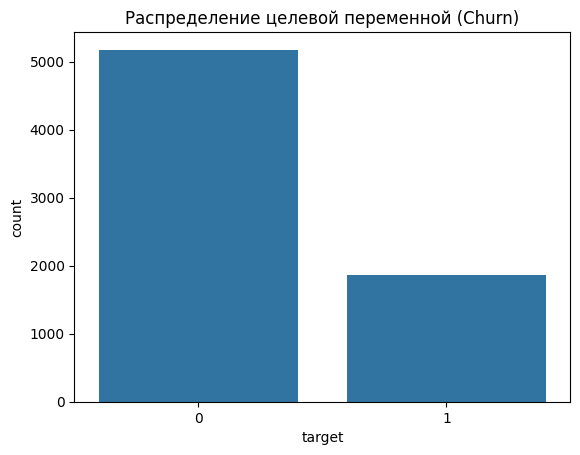

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='target')
plt.title('Распределение целевой переменной (Churn)')
plt.show()

Выводы:
1. Пропуски в данных связаны с отсутствием интернет-услуг — их нужно обрабатывать осмысленно, а не удалять.

2. Целевая переменная несбалансирована — только 27% клиентов ушли. Это важно для выбора метрики и подхода к обучению.

3. Признаки имеют разный масштаб — числовые признаки нужно масштабировать перед обучением.

6. Логи в MLflow как артефакт

In [21]:
import os
import mlflow
from dotenv import load_dotenv

load_dotenv()

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("churn_project_experiment")

with mlflow.start_run(run_name="eda_analysis") as run:
    run_id = run.info.run_id
    mlflow.log_artifact("eda.ipynb")
    print("✅ EDA блокнот залогирован")
    print("🔗 Run ID:", run_id)

✅ EDA блокнот залогирован
🔗 Run ID: e20ef056673446628f2f0ca5f3884df5


In [22]:
import mlflow
from mlflow.tracking import MlflowClient

client = MlflowClient()

run_id = "ec48c2a516914c41bb82002f053829b6"

artifacts = client.list_artifacts(run_id)

print("Артефакты в запуске:")
for a in artifacts:
    print(f" - {a.path} ({a.file_size} bytes)")

Артефакты в запуске:
 - eda.ipynb (42111 bytes)


Этап 3. Генерация признаков и обучение модели

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

print("DB_HOST:", os.getenv("DB_DESTINATION_HOST"))
print("DB_NAME:", os.getenv("DB_DESTINATION_NAME"))

DB_HOST: rc1b-uh7kdmcx67eomesf.mdb.yandexcloud.net
DB_NAME: playground_mle_20260624_4fe40d5155


In [5]:
import os
import pandas as pd
import psycopg2
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, log_loss
from autofeat import AutoFeatClassifier

# ====== ЗАГРУЗКА ДАННЫХ ======
connection = {
    "sslmode": "require",
    "target_session_attrs": "read-write",
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

with psycopg2.connect(**connection) as conn:
    with conn.cursor() as cur:
        cur.execute("SELECT * FROM users_churn")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

# ====== ПРИЗНАКИ ======
cat_features = [
    'type', 'paperless_billing', 'payment_method', 'internet_service',
    'online_security', 'online_backup', 'device_protection', 'tech_support',
    'streaming_tv', 'streaming_movies', 'gender', 'partner', 'dependents', 'multiple_lines'
]

num_features = ['monthly_charges', 'total_charges', 'senior_citizen']

# ====== ЗАПОЛНЕНИЕ ПРОПУСКОВ ======
for col in cat_features:
    df[col] = df[col].fillna("missing")

for col in num_features:
    df[col] = df[col].fillna(df[col].median())

# ====== РАЗБИЕНИЕ ======
X = df.drop(columns=['target', 'customer_id', 'begin_date', 'end_date'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ====== COLUMNTRANSFORMER ======
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('kbins', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform'))
    ]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]), cat_features)
], remainder='drop')

# ====== МОДЕЛЬ ======
model = CatBoostClassifier(
    loss_function="Logloss",
    task_type="CPU",
    random_seed=0,
    iterations=300,
    verbose=False
)

# ====== PIPELINE ======
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', model)
])

# ====== ОБУЧЕНИЕ ======
pipeline.fit(X_train, y_train)

# ====== ПРЕДСКАЗАНИЯ ======
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# ====== МЕТРИКИ ======
metrics = {
    'auc': roc_auc_score(y_test, y_proba),
    'f1': f1_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'logloss': log_loss(y_test, y_proba)
}

print("✅ Метрики после генерации признаков:")
print(metrics)

# ====== AUTOFEAT ======
afc = AutoFeatClassifier(
    categorical_cols=cat_features,
    transformations=('1/', 'log', 'abs', 'sqrt'),
    feateng_steps=1,
    n_jobs=-1,
    verbose=0
)

X_train_feat = afc.fit_transform(X_train, y_train)
X_test_feat = afc.transform(X_test)

# ====== ОБУЧЕНИЕ НА AUTOFEAT ======
model_af = CatBoostClassifier(
    loss_function="Logloss",
    task_type="CPU",
    random_seed=0,
    iterations=300,
    verbose=False
)

model_af.fit(X_train_feat, y_train)

y_pred_af = model_af.predict(X_test_feat)
y_proba_af = model_af.predict_proba(X_test_feat)[:, 1]

metrics_af = {
    'auc': roc_auc_score(y_test, y_proba_af),
    'f1': f1_score(y_test, y_pred_af),
    'precision': precision_score(y_test, y_pred_af),
    'recall': recall_score(y_test, y_pred_af),
    'logloss': log_loss(y_test, y_proba_af)
}

print("✅ Метрики после autofeat:")
print(metrics_af)

# ====== ЛОГИРОВАНИЕ В MLflow ======
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_registry_uri("http://127.0.0.1:5000")

EXPERIMENT_NAME = "churn_project_experiment"
RUN_NAME = "feature_engineering"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

    mlflow.log_params({
        "iterations": 300,
        "loss_function": "Logloss",
        "task_type": "CPU",
        "random_seed": 0,
        "poly_degree": 2,
        "kbins_n_bins": 5
    })

    mlflow.log_metrics(metrics_af)

    signature = mlflow.models.infer_signature(X_test_feat, y_pred_af)
    input_example = X_test_feat[:5]

    model_info = mlflow.catboost.log_model(
        cb_model=model_af,
        artifact_path="models",
        registered_model_name="churn_model_feature_engineering",
        signature=signature,
        input_example=input_example
    )

    print(f"✅ Модель зарегистрирована")
    print(f"   Run ID: {run_id}")
    print(f"   Experiment ID: {experiment_id}")
    print(f"   Experiment Name: {EXPERIMENT_NAME}")

/home/mle-user/mle_projects/mle-project-sprint-2/venv/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


✅ Метрики после генерации признаков:
{'auc': 0.840250356942999, 'f1': 0.591044776119403, 'precision': 0.6534653465346535, 'recall': 0.5395095367847411, 'logloss': 0.4214721749199574}


/home/mle-user/mle_projects/mle-project-sprint-2/venv/lib/python3.10/site-packages/autofeat/featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:


✅ Метрики после autofeat:
{'auc': 0.8602836193235605, 'f1': 0.6051437216338881, 'precision': 0.6802721088435374, 'recall': 0.5449591280653951, 'logloss': 0.39785474546832306}


/home/mle-user/mle_projects/mle-project-sprint-2/venv/lib/python3.10/site-packages/mlflow/models/signature.py:212: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  inputs = _infer_schema(model_input) if model_input is not None else None
2026-09-01 14:57:56,623 INFO: Found credentials in environment variables.
Successfully registered model 'churn_model_feature_engineering'.
202

✅ Модель зарегистрирована
   Run ID: 7e37fc13a238410785304771594648c0
   Experiment ID: 6
   Experiment Name: churn_project_experiment


Created version '1' of model 'churn_model_feature_engineering'.


Этап 4. Отбор признаков (SFS)

In [6]:
# ====== ЗАГРУЗКА ДАННЫХ ======
import os
import pandas as pd
import psycopg2

connection = {
    "sslmode": "require",
    "target_session_attrs": "read-write",
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

with psycopg2.connect(**connection) as conn:
    with conn.cursor() as cur:
        cur.execute("SELECT * FROM users_churn")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

# ====== ПРИЗНАКИ ======
cat_features = [
    'type', 'paperless_billing', 'payment_method', 'internet_service',
    'online_security', 'online_backup', 'device_protection', 'tech_support',
    'streaming_tv', 'streaming_movies', 'gender', 'partner', 'dependents', 'multiple_lines'
]

num_features = ['monthly_charges', 'total_charges', 'senior_citizen']

for col in cat_features:
    df[col] = df[col].fillna("missing")
for col in num_features:
    df[col] = df[col].fillna(df[col].median())

X = df.drop(columns=['target', 'customer_id', 'begin_date', 'end_date'])
y = df['target']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ====== AUTOFEAT (повтор) ======
from autofeat import AutoFeatClassifier

afc = AutoFeatClassifier(
    categorical_cols=cat_features,
    transformations=('1/', 'log', 'abs', 'sqrt'),
    feateng_steps=1,
    n_jobs=-1,
    verbose=0
)

X_train_feat = afc.fit_transform(X_train, y_train)
X_test_feat = afc.transform(X_test)

print("✅ Данные для отбора признаков готовы")
print(f"X_train_feat shape: {X_train_feat.shape}")

/home/mle-user/mle_projects/mle-project-sprint-2/venv/lib/python3.10/site-packages/autofeat/featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:


✅ Данные для отбора признаков готовы
X_train_feat shape: (5634, 43)


In [7]:
print(X_train_feat.shape)
print(y_train.shape)

(5634, 43)
(5634,)


In [11]:
# ====== ЭТАП 4: ОТБОР ПРИЗНАКОВ (SFS) ======
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, log_loss
import mlflow
import numpy as np

# ====== МОДЕЛЬ ДЛЯ ОТБОРА ======
model_sfs = CatBoostClassifier(
    loss_function="Logloss",
    task_type="CPU",
    random_seed=0,
    iterations=200,
    verbose=False
)

# ====== SFS ======
sfs = SFS(
    model_sfs,
    k_features=15,
    forward=True,
    floating=False,
    scoring='roc_auc',
    cv=2,
    n_jobs=-1
)

print("⏳ Запуск SFS... (5–10 минут)")
sfs.fit(X_train_feat, y_train)

print("✅ Отбор признаков завершён")
print("Лучшие признаки (индексы):", sfs.k_feature_idx_)
print("CV Score:", sfs.k_score_)

# ====== ОБУЧЕНИЕ НА ОТОБРАННЫХ ПРИЗНАКАХ ======
selected_features = list(sfs.k_feature_idx_)

# Преобразуем в numpy
X_train_feat_np = X_train_feat.values if hasattr(X_train_feat, 'values') else X_train_feat
X_test_feat_np = X_test_feat.values if hasattr(X_test_feat, 'values') else X_test_feat

X_train_sel = X_train_feat_np[:, selected_features]
X_test_sel = X_test_feat_np[:, selected_features]

model_final = CatBoostClassifier(
    loss_function="Logloss",
    task_type="CPU",
    random_seed=0,
    iterations=300,
    verbose=False
)

model_final.fit(X_train_sel, y_train)

y_pred_final = model_final.predict(X_test_sel)
y_proba_final = model_final.predict_proba(X_test_sel)[:, 1]

metrics_final = {
    'auc': roc_auc_score(y_test, y_proba_final),
    'f1': f1_score(y_test, y_pred_final),
    'precision': precision_score(y_test, y_pred_final),
    'recall': recall_score(y_test, y_pred_final),
    'logloss': log_loss(y_test, y_proba_final)
}

print("✅ Метрики после отбора признаков:")
print(metrics_final)

# ====== ЛОГИРОВАНИЕ ======
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_registry_uri("http://127.0.0.1:5000")
mlflow.set_experiment("churn_project_experiment")

with mlflow.start_run(run_name="feature_selection") as run:
    run_id = run.info.run_id
    mlflow.log_metrics(metrics_final)
    mlflow.log_params({"k_features": 15, "method": "SFS"})

    signature = mlflow.models.infer_signature(X_test_sel, y_pred_final)
    input_example = X_test_sel[:5]

    model_info = mlflow.catboost.log_model(
        cb_model=model_final,
        artifact_path="models",
        registered_model_name="churn_model_feature_selection",
        signature=signature,
        input_example=input_example
    )

    print(f"✅ Модель зарегистрирована")
    print(f"   Run ID: {run_id}")

⏳ Запуск SFS... (5–10 минут)


✅ Отбор признаков завершён
Лучшие признаки (индексы): (0, 1, 2, 3, 5, 6, 10, 11, 12, 16, 17, 31, 32, 39, 42)
CV Score: 0.8420012426155251
✅ Метрики после отбора признаков:
{'auc': 0.8590598147557359, 'f1': 0.6220238095238095, 'precision': 0.6852459016393443, 'recall': 0.5694822888283378, 'logloss': 0.3999293428678908}


Registered model 'churn_model_feature_selection' already exists. Creating a new version of this model...
2026/09/01 16:04:29 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: churn_model_feature_selection, version 3


✅ Модель зарегистрирована
   Run ID: 11f93f1242244603b22ae4451c9ea4e5


Created version '3' of model 'churn_model_feature_selection'.


Этап 5. Подбор гиперпараметров (Optuna + Grid Search)

In [13]:
# ====== ЭТАП 5: ПОДБОР ГИПЕРПАРАМЕТРОВ ======
import optuna
import mlflow
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, log_loss
from optuna.integration.mlflow import MLflowCallback

# Используем отобранные признаки
X_train_sel = X_train_feat_np[:, selected_features]
X_test_sel = X_test_feat_np[:, selected_features]

# ====== 1. OPTUNA ======
def objective(trial):
    param = {
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'iterations': trial.suggest_int('iterations', 100, 500),
    }
    model = CatBoostClassifier(**param, verbose=False, random_seed=42)
    model.fit(X_train_sel, y_train)
    preds = model.predict_proba(X_test_sel)[:, 1]
    return roc_auc_score(y_test, preds)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

best_params_optuna = study.best_params
print("✅ Лучшие параметры Optuna:", best_params_optuna)

# ====== 2. GRID SEARCH ======
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.1, 0.2],
    'l2_leaf_reg': [3, 5, 7],
    'iterations': [200, 300, 400]
}

model = CatBoostClassifier(verbose=False, random_seed=42)
grid_search = GridSearchCV(model, param_grid, cv=2, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_sel, y_train)

best_params_grid = grid_search.best_params_
print("✅ Лучшие параметры Grid Search:", best_params_grid)

# ====== 3. ВЫБОР ЛУЧШЕЙ МОДЕЛИ ======
if grid_search.best_score_ >= study.best_value:
    best_params = best_params_grid
    method = "Grid Search"
else:
    best_params = best_params_optuna
    method = "Optuna"

print(f"✅ Лучший метод: {method}, лучшие параметры: {best_params}")

# ====== 4. ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ ======
model_final = CatBoostClassifier(**best_params, verbose=False, random_seed=42)
model_final.fit(X_train_sel, y_train)

y_pred_final = model_final.predict(X_test_sel)
y_proba_final = model_final.predict_proba(X_test_sel)[:, 1]

metrics_final = {
    'auc': roc_auc_score(y_test, y_proba_final),
    'f1': f1_score(y_test, y_pred_final),
    'precision': precision_score(y_test, y_pred_final),
    'recall': recall_score(y_test, y_pred_final),
    'logloss': log_loss(y_test, y_proba_final)
}

print("✅ Метрики финальной модели:")
print(metrics_final)

# ====== 5. ЛОГИРОВАНИЕ ======
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_registry_uri("http://127.0.0.1:5000")
mlflow.set_experiment("churn_project_experiment")

with mlflow.start_run(run_name="hyperparameter_tuning") as run:
    run_id = run.info.run_id
    mlflow.log_metrics(metrics_final)
    mlflow.log_params(best_params)
    mlflow.log_param("best_method", method)

    signature = mlflow.models.infer_signature(X_test_sel, y_pred_final)
    input_example = X_test_sel[:5]

    model_info = mlflow.catboost.log_model(
        cb_model=model_final,
        artifact_path="models",
        registered_model_name="churn_model_final",
        signature=signature,
        input_example=input_example
    )

    print(f"✅ Финальная модель зарегистрирована")
    print(f"   Run ID: {run_id}")

[I 2026-09-01 16:30:30,571] A new study created in memory with name: no-name-d88df6ab-eea8-4c0b-a0e9-0f8a6ad089f7


[I 2026-09-01 16:30:31,634] Trial 0 finished with value: 0.8455352053010611 and parameters: {'depth': 5, 'learning_rate': 0.2536999076681772, 'l2_leaf_reg': 7.587945476302646, 'iterations': 340}. Best is trial 0 with value: 0.8455352053010611.
[I 2026-09-01 16:30:32,844] Trial 1 finished with value: 0.8633928151166015 and parameters: {'depth': 4, 'learning_rate': 0.01699897838270077, 'l2_leaf_reg': 1.5227525095137953, 'iterations': 447}. Best is trial 1 with value: 0.8633928151166015.
[I 2026-09-01 16:30:35,474] Trial 2 finished with value: 0.8397456683071226 and parameters: {'depth': 7, 'learning_rate': 0.11114989443094977, 'l2_leaf_reg': 1.185260448662222, 'iterations': 488}. Best is trial 1 with value: 0.8633928151166015.
[I 2026-09-01 16:30:37,065] Trial 3 finished with value: 0.8623232936032675 and parameters: {'depth': 9, 'learning_rate': 0.020589728197687916, 'l2_leaf_reg': 2.636424704863906, 'iterations': 173}. Best is trial 1 with value: 0.8633928151166015.
[I 2026-09-01 16:30

✅ Лучшие параметры Optuna: {'depth': 4, 'learning_rate': 0.014265072629010268, 'l2_leaf_reg': 5.1590328256101525, 'iterations': 499}
✅ Лучшие параметры Grid Search: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
✅ Лучший метод: Optuna, лучшие параметры: {'depth': 4, 'learning_rate': 0.014265072629010268, 'l2_leaf_reg': 5.1590328256101525, 'iterations': 499}
✅ Метрики финальной модели:
{'auc': 0.8635915526105216, 'f1': 0.6207951070336392, 'precision': 0.7073170731707317, 'recall': 0.553133514986376, 'logloss': 0.39440957834167084}


Registered model 'churn_model_final' already exists. Creating a new version of this model...
2026/09/01 16:35:02 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: churn_model_final, version 2


✅ Финальная модель зарегистрирована
   Run ID: 2c2538bfebbe4649859b56d1b8fb212b


Created version '2' of model 'churn_model_final'.
